# Student Performance Dataset: Predicting Academic Performance
This notebook uses linear regression to predict the student performance index from study habits and background attributes.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

## Data Inspection
The dataset is loaded, the target column is separated, and the data is split into training and test sets.


<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 9254 to 7270
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     8000 non-null   int64 
 1   Previous Scores                   8000 non-null   int64 
 2   Extracurricular Activities        8000 non-null   object
 3   Sleep Hours                       8000 non-null   int64 
 4   Sample Question Papers Practiced  8000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 375.0+ KB


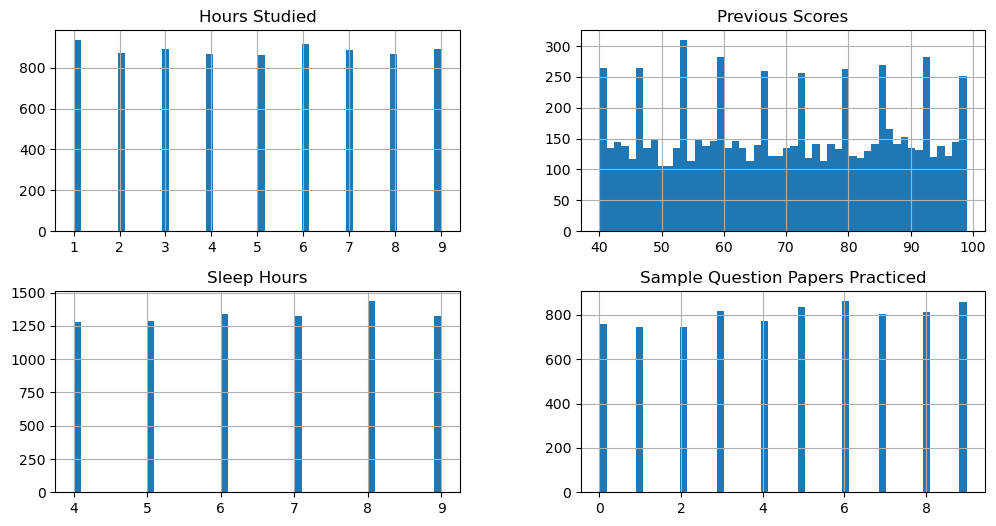

In [2]:
df = pd.read_csv("../data/students.csv")
X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.hist(figsize=(12, 6), bins=50)
X_train.info()

## Preprocessing
Numerical features are standardized and categorical features are one-hot encoded.


In [3]:
num_pipeline = make_pipeline(
    StandardScaler()
)

cat_pipeline = make_pipeline(
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, X_train.select_dtypes(include=["int64"]).columns),
    ("cat", cat_pipeline, ["Extracurricular Activities"])
])

## Model
A linear regression model is trained inside the preprocessing pipeline.


## Evaluation
The model is evaluated on the test set with R2 and error-based regression metrics.


Test R2: 0.9889832909573145
Test MSE: 4.082628398521855
Test RMSE: 2.020551508505006
Test MAE: 1.6111213463123044


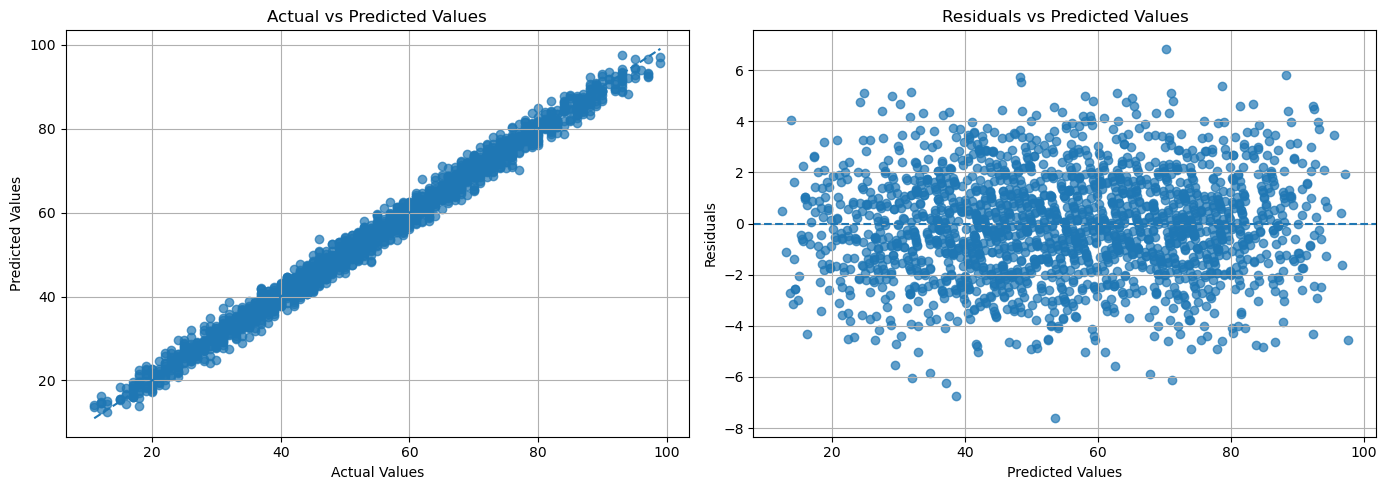

In [4]:
model = make_pipeline(
    preprocessing,
    LinearRegression()
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Test R2:", r2_score(y_test, y_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("Test MAE:", mean_absolute_error(y_test, y_pred))

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--")
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Actual vs Predicted Values")
axes[0].grid(True)

# 2. Residuals vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.7)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Predicted Values")
axes[1].grid(True)

plt.tight_layout()
plt.show()